# Build Subreddit Similarity Graph

Notebook nay dung content-based graph tu edge list similarity da duoc loc percentile:
- Node: `subreddit`
- Edge: ton tai khi 2 subreddit co similarity cao
- Weight: `cosine_similarity`

Notebook se:
1. Doc parquet similarity edges
2. Dung `networkx.Graph`
3. Tong hop thong tin graph
4. Ve full graph va subgraph de quan sat de hon


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

# Cho phep chay notebook tu repo root hoac tu thu muc notebooks.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").exists():
    REPO_ROOT = REPO_ROOT.parent

INPUT_PATH = REPO_ROOT / "data/processed/subreddit_cosine_similarity_distilbert.parquet"
GRAPH_RANDOM_SEED = 42
FULL_GRAPH_FIGSIZE = (16, 16)
FOCUSED_GRAPH_FIGSIZE = (14, 14)
FOCUSED_GRAPH_TOP_N = 40

INPUT_PATH

WindowsPath('d:/python/process-local/data/processed/subreddit_cosine_similarity_distilbert.parquet')

In [2]:
REQUIRED_EDGE_COLUMNS = {"source_subreddit", "target_subreddit", "cosine_similarity"}


def load_similarity_edges(input_path: Path) -> pd.DataFrame:
    if not input_path.exists():
        raise FileNotFoundError(f"Missing similarity parquet: {input_path}")

    edge_frame = pd.read_parquet(input_path)
    missing_columns = sorted(REQUIRED_EDGE_COLUMNS - set(edge_frame.columns))
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    edge_frame = edge_frame.loc[:, ["source_subreddit", "target_subreddit", "cosine_similarity"]].copy()
    edge_frame = edge_frame.dropna(subset=["source_subreddit", "target_subreddit", "cosine_similarity"])
    edge_frame = edge_frame.loc[edge_frame["source_subreddit"] != edge_frame["target_subreddit"]]
    edge_frame["cosine_similarity"] = edge_frame["cosine_similarity"].astype(float)

    canonical_pairs = np.sort(
        edge_frame[["source_subreddit", "target_subreddit"]].to_numpy(dtype=object, copy=True),
        axis=1,
    )
    edge_frame["source_subreddit"] = canonical_pairs[:, 0]
    edge_frame["target_subreddit"] = canonical_pairs[:, 1]
    edge_frame = edge_frame.drop_duplicates(subset=["source_subreddit", "target_subreddit"], keep="first")
    edge_frame = edge_frame.sort_values("cosine_similarity", ascending=False).reset_index(drop=True)
    return edge_frame


def build_similarity_graph(edge_frame: pd.DataFrame) -> nx.Graph:
    graph = nx.Graph()
    for edge in edge_frame.itertuples(index=False):
        graph.add_edge(
            edge.source_subreddit,
            edge.target_subreddit,
            weight=float(edge.cosine_similarity),
        )
    return graph


def build_graph_summary(graph: nx.Graph, edge_frame: pd.DataFrame) -> dict[str, object]:
    node_count = graph.number_of_nodes()
    edge_count = graph.number_of_edges()
    weighted_degrees = dict(graph.degree(weight="weight"))
    connected_components = sorted(nx.connected_components(graph), key=len, reverse=True)
    largest_component_size = len(connected_components[0]) if connected_components else 0

    return {
        "nodes": node_count,
        "edges": edge_count,
        "density": nx.density(graph) if node_count > 1 else 0.0,
        "connected_components": len(connected_components),
        "largest_component_nodes": largest_component_size,
        "avg_weighted_degree": float(np.mean(list(weighted_degrees.values()))) if weighted_degrees else 0.0,
        "min_similarity": float(edge_frame["cosine_similarity"].min()) if not edge_frame.empty else 0.0,
        "max_similarity": float(edge_frame["cosine_similarity"].max()) if not edge_frame.empty else 0.0,
        "mean_similarity": float(edge_frame["cosine_similarity"].mean()) if not edge_frame.empty else 0.0,
    }


def get_top_weighted_degree_nodes(graph: nx.Graph, top_n: int) -> list[str]:
    ranked_nodes = sorted(graph.degree(weight="weight"), key=lambda item: item[1], reverse=True)
    return [node for node, _ in ranked_nodes[:top_n]]


def draw_graph(graph: nx.Graph, figsize: tuple[int, int], title: str) -> None:
    if graph.number_of_nodes() == 0:
        raise ValueError("Graph is empty.")

    plt.figure(figsize=figsize)
    position = nx.spring_layout(graph, seed=GRAPH_RANDOM_SEED, weight="weight", k=None)
    weighted_degrees = dict(graph.degree(weight="weight"))
    node_sizes = [120 + weighted_degrees[node] * 80 for node in graph.nodes()]
    edge_weights = [graph[u][v]["weight"] for u, v in graph.edges()]
    edge_widths = [1.0 + (weight * 2.5) for weight in edge_weights]

    nx.draw_networkx_nodes(
        graph,
        position,
        node_size=node_sizes,
        node_color="#1f77b4",
        alpha=0.85,
        linewidths=0.5,
        edgecolors="white",
    )
    nx.draw_networkx_edges(
        graph,
        position,
        width=edge_widths,
        edge_color="#7f8c8d",
        alpha=0.35,
    )
    nx.draw_networkx_labels(graph, position, font_size=8)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [3]:
# Doc edge list similarity va dung content-based graph.
similarity_edges = load_similarity_edges(INPUT_PATH)
graph = build_similarity_graph(similarity_edges)
graph_summary = build_graph_summary(graph, similarity_edges)

assert graph.number_of_edges() == len(similarity_edges)
assert graph.number_of_nodes() == similarity_edges[["source_subreddit", "target_subreddit"]].stack().nunique()

graph_summary

{'nodes': 2534,
 'edges': 134866,
 'density': 0.042023350183263634,
 'connected_components': 57,
 'largest_component_nodes': 2313,
 'avg_weighted_degree': 104.96971582895955,
 'min_similarity': 0.9816910028457642,
 'max_similarity': 0.9995040893554688,
 'mean_similarity': 0.9861390562135137}

In [4]:
# Xem cac edge manh nhat va cac node co weighted degree cao nhat.
top_weighted_degree = pd.DataFrame(
    sorted(graph.degree(weight="weight"), key=lambda item: item[1], reverse=True)[:15],
    columns=["subreddit", "weighted_degree"],
)

display(similarity_edges.head(10))
top_weighted_degree

,source_subreddit,target_subreddit,cosine_similarity
0,ArgentinaBenderStyle,Burises,0.999504
1,BeginnerArtists,Beginner_Art,0.999495
2,AussieGF_OC,AussieSideChicks,0.999396
3,AreTheStraightsOK,AreTheStraightsOkay,0.999369
4,Adaland,Atman96,0.999326
5,AmberlynnReidYT,AmberlynnSnark,0.999292
6,Amberverse_,Amberverse__,0.999270
7,Boxer,Boxers,0.999265
8,BoxerDogs,Boxers,0.999237
9,AxieInfinityScholar,AxieScholarshipsPH,0.999227


,subreddit,weighted_degree
0,CadenMoranDiary,649.836731
1,Bombstrap,645.137792
2,CinnamonToastKen,637.564117
3,ATBandATGcommunity,636.308727
4,CSHFans,632.198293
5,AFKJourney,607.301022
6,Achievement_Hunter,605.947248
7,AgencySquad,601.789129
8,ArcaneOdyssey,600.349192
9,AnimeOT,588.212835


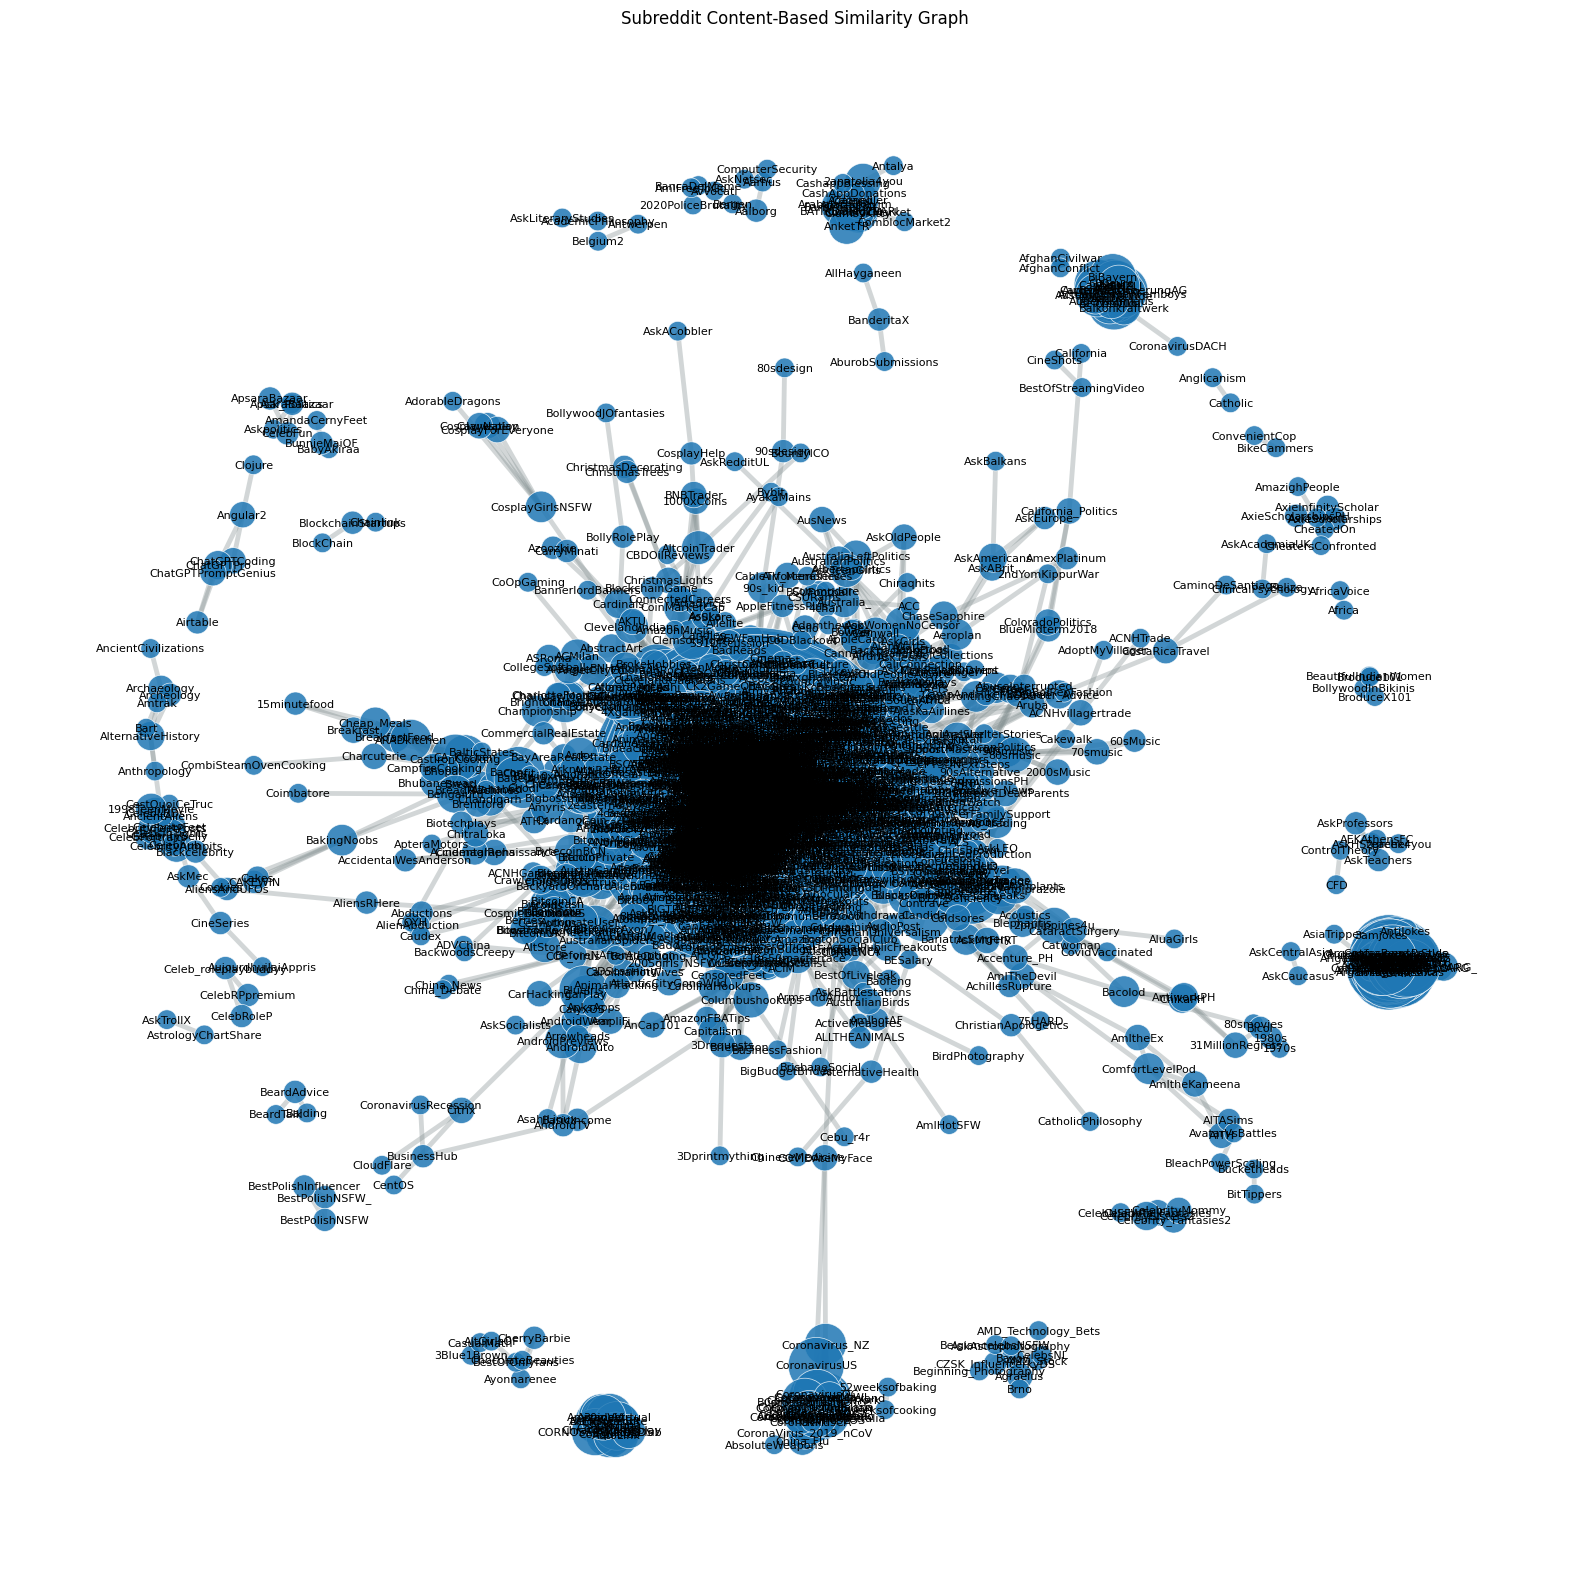

In [5]:
# Ve toan bo graph. Phu hop khi so node khong qua lon.
draw_graph(
    graph,
    figsize=FULL_GRAPH_FIGSIZE,
    title="Subreddit Content-Based Similarity Graph",
)


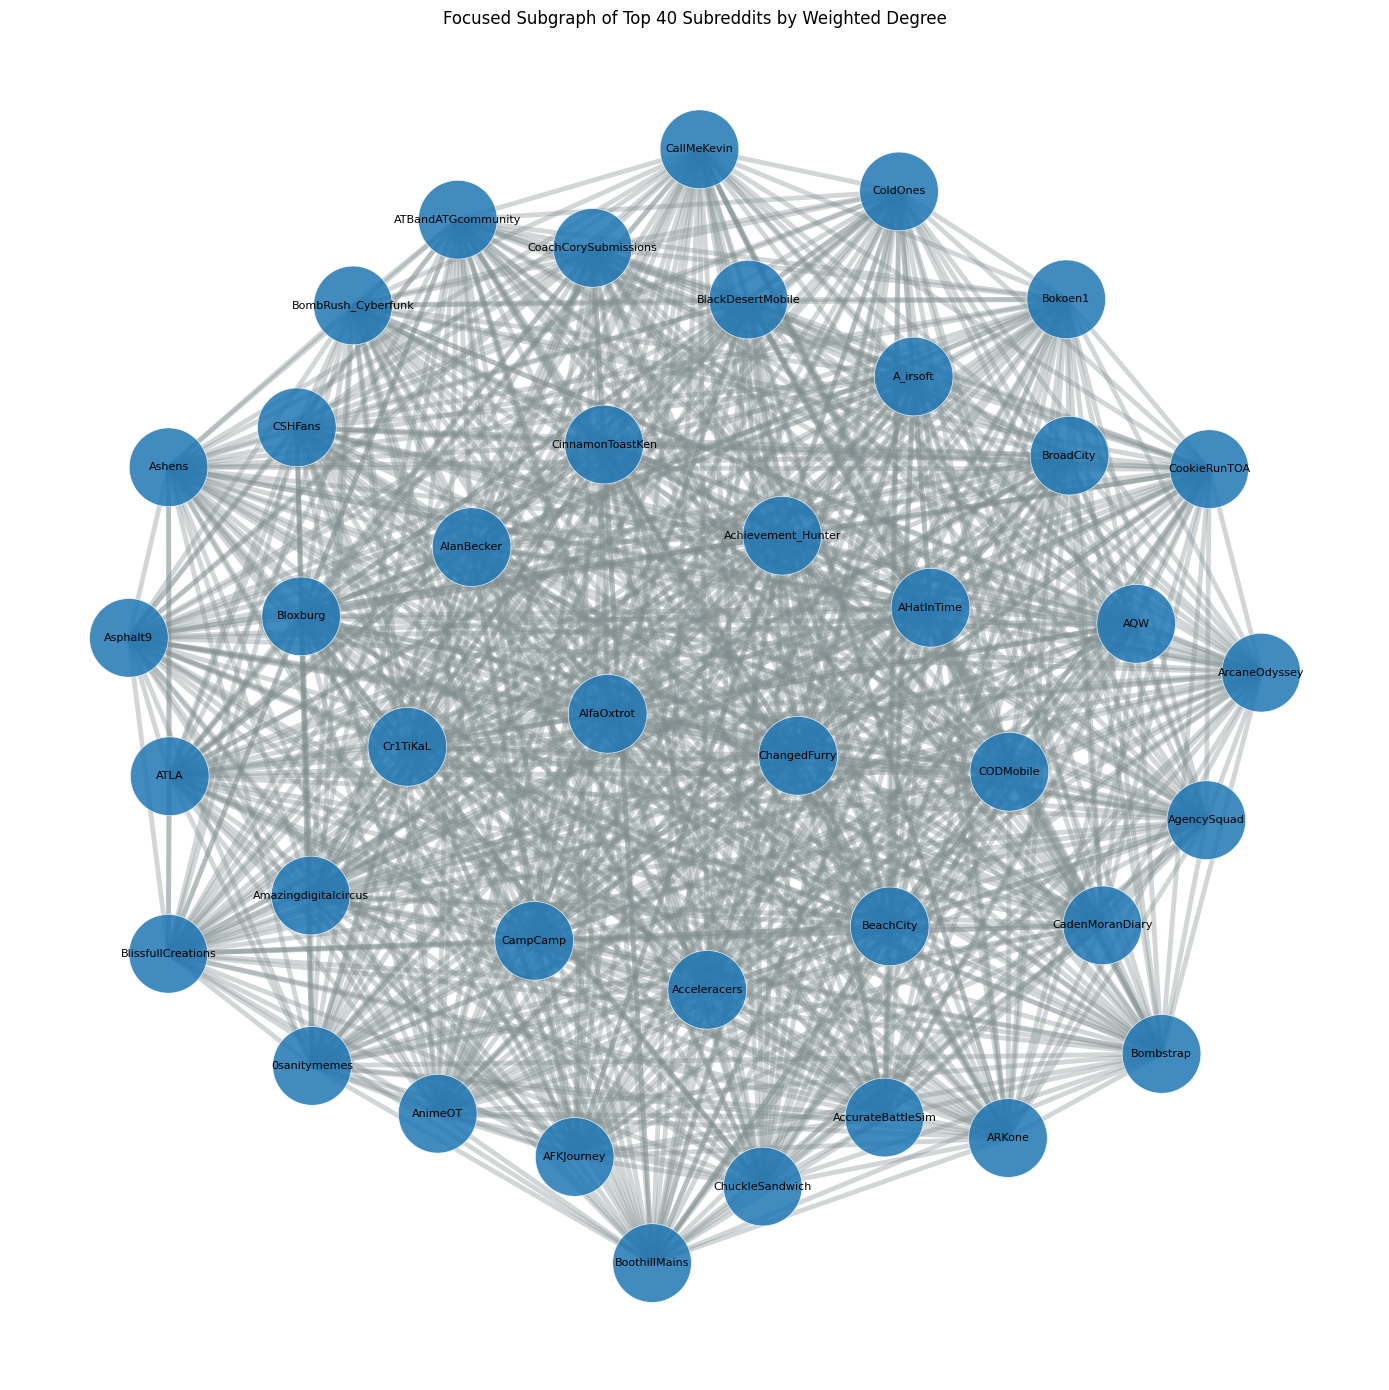

In [6]:
# Ve subgraph cua nhom subreddit trung tam de bieu do de doc hon.
focused_nodes = get_top_weighted_degree_nodes(graph, top_n=FOCUSED_GRAPH_TOP_N)
focused_graph = graph.subgraph(focused_nodes).copy()

draw_graph(
    focused_graph,
    figsize=FOCUSED_GRAPH_FIGSIZE,
    title=f"Focused Subgraph of Top {FOCUSED_GRAPH_TOP_N} Subreddits by Weighted Degree",
)
